# FPC1500 Network Analyzer - S21 (Transmission)

Kurz zur Theorie (Zweitor, Streuparameter):

Ein lineares Zweitor wird mit einlaufenden Wellen $a_1, a_2$ und auslaufenden Wellen $b_1, b_2$ beschrieben:

$$\begin{bmatrix} b_1 \\ b_2 \end{bmatrix} =
\begin{bmatrix} S_{11} & S_{12} \\ S_{21} & S_{22} \end{bmatrix}
\begin{bmatrix} a_1 \\ a_2 \end{bmatrix}$$

Mit Anregung an Port 1 und Abschluss an Port 2 ($a_2=0$) gilt:

$$S_{21} = \frac{b_2}{a_1}$$

Damit ist $S_{21}$ der Vorwärts-Transmissionsfaktor (Durchlass vom Eingang Port 1 zum Ausgang Port 2).

In diesem Notebook wird **einmal** `TRACE1` als Transmission gelesen und als
**Return/Transmission-Darstellung in dB** geplottet: $20\log_{10}(|S_{21}|)$.

Am Ende wird ein Screenshot vom Gerät eingelesen.

## Eigene Messung von S21 eines Hochfrequenz-Filters
Wähle einen passenden, aussagekräftigen Frequenzbereich, und führe vor der Messung eine Kalibration für diesen gewählten mit dem Notebook 1-fpc1500-NA-S21.ipynb durch !. (Anmerkung: das Gerät als Network-Analyzer arbeitet erst ab 2 MHz).  

- Nach der erfolgten Kalibraion gemäß dem Notebook 1-fpc1500-NA-S21.ipynb führe HIER die Messung der Transmission S21 dieses Hochfrequenz-Filters durch.

Die Messung mit diesem Notebook erfolgte bereits vorab, die Messdaten stehen für die Analyse bereit.

Das Notebook 3-fpc1500-NA-S21.ipynb soll dann im Labor für eine **eigene Messung und Analyse** genutzt werden.  

### Führe das Notebook im Modus REPLAY = False für die Messung, und später mit REPLAY = True für diese Analysen aus:

- Bestimme die Art des Filters.
- Ermittle die 3 dB Grenzfrequenzen sowie die Filterbandbreite B.
- Ermittle die Einfügungsdämpfung (minimale Dämpfung im Durchlassbereich).
- Bestimme den maximalen Rolloff-Slope (Steigung der Filter-Dämpfungskurve, angegeben in dB/Oktave sowie in dB/Dekade).
- Wir nehmen an, es sei ein RF-Generator mit einer Rauschtemperatur von 320K an das Filter angeschlossen. Wie groß wäre die LEsitung des gefilterten Generator-Rauschsignals?


Implementiere **Python-Code** in der dafür markierten Code-Zelle am Ende des Notebooks mit kurzer Erklärung und klar formulierten Antwortsätzen, achte auch auf die korrekten Einheiten der Lösungswerte (d.h. Angabe von Zahlenwert **und** Einheit der Größe).


 





![S21 Normalization ](media\S21-rf-filter.jpg)

## Imports und Globale Parameter

In [1]:
import json
import socket
from datetime import datetime
from pathlib import Path

# Interaktive Matplotlib-Widgets (Slider) in Jupyter: ipympl installieren, dann:
#   pip install ipympl
# Ohne ipympl nutzt oft das statische "inline"-Backend — der Slider erscheint, ist aber nicht ziehbar.
try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "widget")
except Exception:
    pass

import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import numpy as np
from IPython.display import Image, display

FPC_IP = "192.168.1.10"
FPC_PORT = 5555
SOCKET_TIMEOUT = 5.0
SCREENSHOT_TIMEOUT = 15.0   # HCOP und Auslesen können deutlich länger als 5 s dauern
TRACE_READ_MAX_BYTES = 2 * 1024 * 1024

# Offline-Workflow: bei REPLAY=True werden Messdaten aus JSON geladen
REPLAY = True
REPLAY_FILE = Path("recordings") / "3-fpc1500_na_s21_replay.json"

SCREENSHOT_DIR = Path("screenshots")
SCREENSHOT_FILENAME = "screen.png"

print(f"Konfiguration: {FPC_IP}:{FPC_PORT}")
print(f"REPLAY={REPLAY}, Datei={REPLAY_FILE}")

Konfiguration: 192.168.1.10:5555
REPLAY=True, Datei=recordings\3-fpc1500_na_s21_replay.json


In [2]:
def scpi_query(host: str, port: int, cmd: str, timeout: float = SOCKET_TIMEOUT, max_bytes: int = 4096) -> str:
    cmd = cmd.strip() + "\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(timeout)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while len(buf) < max_bytes:
            chunk = s.recv(8192)
            if not chunk:
                break
            buf += chunk
            if b"\n" in buf:
                break
        return buf.decode("utf-8", errors="replace").strip()
    finally:
        s.close()

def parse_float_list(raw: str) -> np.ndarray:
    vals = []
    for part in raw.replace(",", " ").split():
        try:
            vals.append(float(part))
        except ValueError:
            continue
    return np.asarray(vals, dtype=np.float64)

def get_freq_axis(host: str, port: int, n: int) -> np.ndarray:
    try:
        f_start = float(scpi_query(host, port, "FREQ:STAR?", max_bytes=256))
        f_stop = float(scpi_query(host, port, "FREQ:STOP?", max_bytes=256))
    except Exception:
        cent = float(scpi_query(host, port, "FREQ:CENT?", max_bytes=256))
        span = float(scpi_query(host, port, "FREQ:SPAN?", max_bytes=256))
        f_start = cent - span / 2.0
        f_stop = cent + span / 2.0
    return np.linspace(f_start, f_stop, n)

def to_s21_db(vals: np.ndarray) -> tuple[np.ndarray, str]:
    if vals.size == 0:
        return vals, "empty"
    vmin = float(np.nanmin(vals))
    vmax = float(np.nanmax(vals))
    looks_like_db = vmax <= 40.0 and vmin < 20.0
    if looks_like_db:
        return vals, "already_dB"
    s21_db = 20.0 * np.log10(np.maximum(np.abs(vals), 1e-12))
    return s21_db, "linear_to_dB"


def save_replay_json(path: Path, data: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2), encoding="utf-8")


def load_replay_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"Replay-Datei nicht gefunden: {path}")
    return json.loads(path.read_text(encoding="utf-8"))


def screenshot_save(host: str, port: int, filename: str = "screen.png") -> str | None:
    """Hardcopy auf dem Gerät auslösen und in MMEM speichern. Returns None bei Erfolg, sonst Fehlermeldung."""
    commands = ["HCOP:DEV:LANG PNG", "HCOP:DEST 'MMEM'", f"MMEM:NAME '{filename}'", "HCOP:IMM"]
    cmd = "\n".join(commands) + "\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(SCREENSHOT_TIMEOUT)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while len(buf) < 4096:
            try:
                chunk = s.recv(1024)
                if not chunk:
                    break
                buf += chunk
                if b"\n" in buf:
                    break
            except socket.timeout:
                break
        reply = buf.decode("utf-8", errors="replace").strip()
        if reply and "error" in reply.lower():
            return reply
        return None
    except Exception as e:
        return str(e)
    finally:
        s.close()


def screenshot_read(host: str, port: int, filename: str) -> bytes | None:
    """Datei vom Gerät (MMEM) lesen. MMEM:DATA? Antwort im IEEE 488.2-Blockformat. Returns PNG-Bytes oder None."""
    cmd = f"MMEM:DATA? '{filename}'\n"
    s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
    s.settimeout(SCREENSHOT_TIMEOUT)
    try:
        s.connect((host, port))
        s.sendall(cmd.encode())
        buf = b""
        while b"#" not in buf and len(buf) < 1024:
            chunk = s.recv(256)
            if not chunk:
                return None
            buf += chunk
        if b"#" not in buf:
            return None
        start = buf.index(b"#")
        buf = buf[start:]
        if len(buf) < 2:
            buf += s.recv(2 - len(buf))
        n_digits = int(chr(buf[1]))
        if n_digits < 1 or n_digits > 9:
            return None
        while len(buf) < 2 + n_digits:
            buf += s.recv(2 + n_digits - len(buf))
        data_len = int(buf[2 : 2 + n_digits].decode())
        buf = buf[2 + n_digits :]
        while len(buf) < data_len:
            chunk = s.recv(min(65536, data_len - len(buf)))
            if not chunk:
                break
            buf += chunk
        return buf[:data_len] if len(buf) >= data_len else None
    except Exception:
        return None
    finally:
        s.close()

## Messung S21 aus TRACE1

Bitte am Gerät die Transmission (S21) aktiv darstellen und dann diese Zelle ausführen.
Die Zelle liest `TRACE1` einmal ein und plottet $20\log_{10}(|S_{21}|)$ über der Frequenz.

Replay geladen: recordings\3-fpc1500_na_s21_replay.json
Gerät: Rohde&Schwarz,FPC1500,1328.6660K03/206021,V1.90


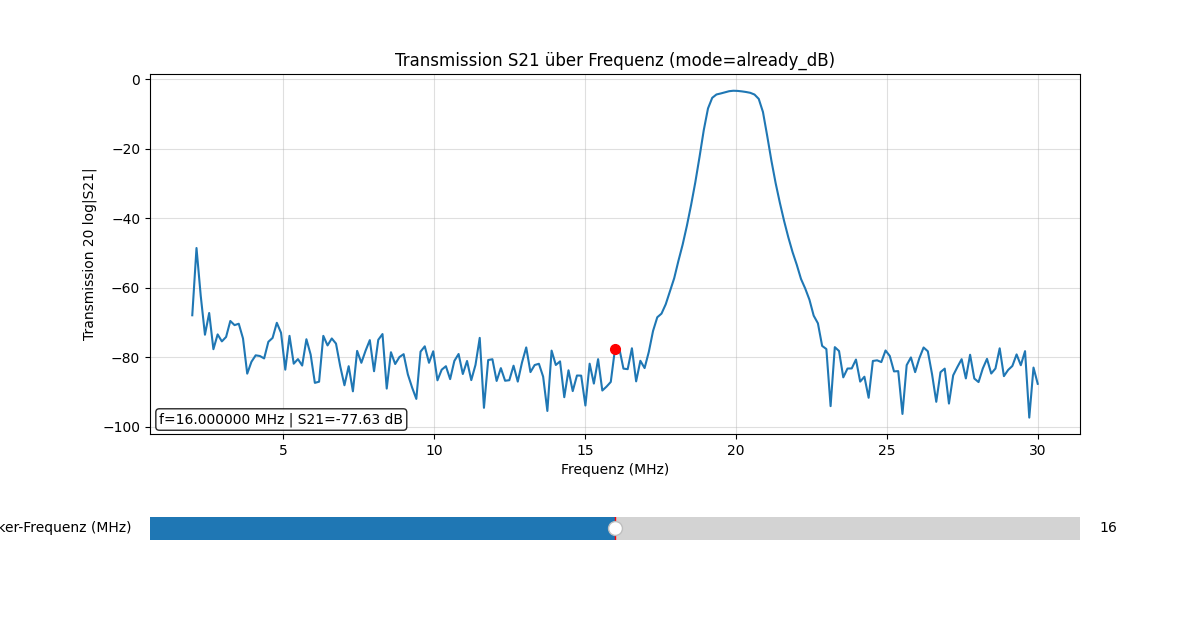

In [3]:
if REPLAY:
    replay = load_replay_json(REPLAY_FILE)
    freq_hz = np.asarray(replay["freq_hz"], dtype=float)
    trace_vals = np.asarray(replay["trace_vals"], dtype=float)
    s21_db = np.asarray(replay["s21_db"], dtype=float)
    s21_mode = replay.get("s21_mode", "replay")
    idn = replay.get("idn", "REPLAY")
    print("Replay geladen:", REPLAY_FILE)
    print("Gerät:", idn)
else:
    idn = scpi_query(FPC_IP, FPC_PORT, "*IDN?")
    print("Gerät:", idn if idn else "Keine Antwort")

    trace_raw = scpi_query(FPC_IP, FPC_PORT, "TRAC:DATA? TRACE1", max_bytes=TRACE_READ_MAX_BYTES)
    trace_vals = parse_float_list(trace_raw)
    if trace_vals.size < 2:
        raise RuntimeError("TRACE1 leer. Bitte S21-Transmission am Gerät einstellen.")

    freq_hz = get_freq_axis(FPC_IP, FPC_PORT, trace_vals.size)
    s21_db, s21_mode = to_s21_db(trace_vals)

    save_replay_json(
        REPLAY_FILE,
        {
            "meta": {"type": "fpc1500_na_s21", "version": 1},
            "idn": idn,
            "s21_mode": s21_mode,
            "freq_hz": freq_hz.tolist(),
            "trace_vals": trace_vals.tolist(),
            "s21_db": s21_db.tolist(),
        },
    )
    print("Replay gespeichert:", REPLAY_FILE)

f_mhz = freq_hz / 1e6

fig = plt.figure(figsize=(12, 6.2))
gs = fig.add_gridspec(2, 1, height_ratios=[1.0, 0.13], hspace=0.35)
ax = fig.add_subplot(gs[0, 0])
ax_slider = fig.add_subplot(gs[1, 0])

ax.plot(f_mhz, s21_db, color="C0", lw=1.5)
ax.set_title(f"Transmission S21 über Frequenz (mode={s21_mode})")
ax.set_xlabel("Frequenz (MHz)")
ax.set_ylabel("Transmission 20 log|S21|")
ax.grid(True, alpha=0.4)

idx0 = int(np.argmin(np.abs(f_mhz - np.mean(f_mhz))))
m_s21, = ax.plot([f_mhz[idx0]], [s21_db[idx0]], "o", color="red", ms=7)
# Text im Haupt-Plot (transAxes), nicht fig.text am unteren Figurenrand — sonst überlappt
# der unsichtbare Kasten die Slider-Achse und blockiert Maus-Events.
info_text = ax.text(
    0.01,
    0.02,
    "",
    transform=ax.transAxes,
    fontsize=10,
    ha="left",
    va="bottom",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.85),
)

slider = Slider(
    ax=ax_slider,
    label="Marker-Frequenz (MHz)",
    valmin=float(f_mhz.min()),
    valmax=float(f_mhz.max()),
    valinit=float(f_mhz[idx0]),
)

def update_marker(f_sel_mhz):
    idx = int(np.argmin(np.abs(f_mhz - f_sel_mhz)))
    m_s21.set_data([f_mhz[idx]], [s21_db[idx]])
    info_text.set_text(f"f={f_mhz[idx]:.6f} MHz | S21={s21_db[idx]:.2f} dB")
    fig.canvas.draw_idle()

slider.on_changed(update_marker)
update_marker(f_mhz[idx0])
plt.show()

Replay-Screenshot geladen: screenshots\3-fpc1500_na_s21_screenshot.png


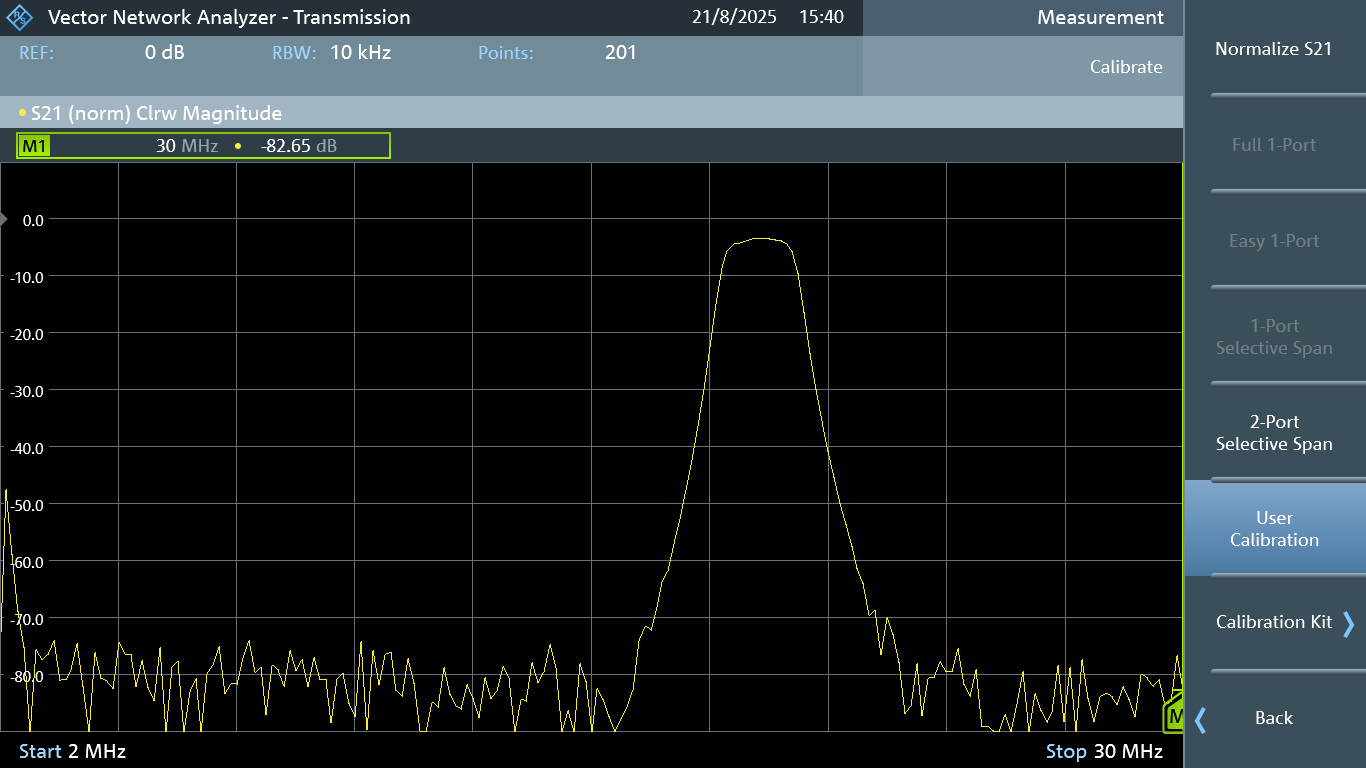

In [4]:
# Screenshot-Handling:
# - REPLAY=False: Screenshot am Gerät auslösen, lokal speichern und Replay-Datei damit verknüpfen
# - REPLAY=True : bereits aufgezeichneten Screenshot aus Replay-Datei anzeigen (kein neuer Trigger)
# (Am Gerät sollte bei Live-Messung die S21-Transmission sichtbar sein.)

SCREENSHOT_DIR.mkdir(parents=True, exist_ok=True)

if REPLAY:
    replay = load_replay_json(REPLAY_FILE)
    shot_path_str = replay.get('screenshot_path', '')
    shot_path = Path(shot_path_str) if shot_path_str else None

    if shot_path and shot_path.exists():
        print('Replay-Screenshot geladen:', shot_path)
        display(Image(filename=str(shot_path)))
    else:
        print('REPLAY=True: Kein gültiger screenshot_path in Replay-Datei vorhanden.')
        if shot_path_str:
            print('Gespeicherter Pfad (nicht gefunden):', shot_path_str)
else:
    err = screenshot_save(FPC_IP, FPC_PORT, SCREENSHOT_FILENAME)
    if err:
        print('Screenshot speichern auf dem Gerät fehlgeschlagen:', err)
    else:
        png_bytes = screenshot_read(FPC_IP, FPC_PORT, SCREENSHOT_FILENAME)
        if png_bytes:
            out_path = SCREENSHOT_DIR / f"{REPLAY_FILE.stem.replace('_replay', '')}_screenshot.png"
            out_path.write_bytes(png_bytes)
            print('Gespeichert:', out_path.resolve())
            display(Image(data=png_bytes))

            try:
                replay = load_replay_json(REPLAY_FILE) if REPLAY_FILE.exists() else {}
                replay['screenshot_path'] = str(out_path)
                save_replay_json(REPLAY_FILE, replay)
                print('Replay aktualisiert mit screenshot_path:', REPLAY_FILE)
            except Exception as ex:
                print('Hinweis: screenshot_path konnte nicht im Replay gespeichert werden:', ex)
        else:
            print('Screenshot konnte nicht gelesen werden.')

## Erstelle **HIER** die Mess-Analyse mit Python-Code

S21-ANALYSE DES HOCHFREQUENZ-FILTERS

Maximale Transmission: -3.370 dB
Frequenz der maximalen Transmission: 19.920000 MHz

Vermutete Filterart: Bandpass

--- 3-dB-Grenzen ---
3-dB-Pegel:       -6.370 dB
Untere Grenzfrequenz: 19.175700 MHz
Obere Grenzfrequenz:  20.900000 MHz
Filterbandbreite B:   1.724300 MHz

--- Einfügungsdämpfung ---
Minimale Dämpfung / Einfügungsdämpfung: 3.370 dB

--- Maximaler Rolloff-Slope ---
Frequenz:              29.580000 MHz
Max. Rolloff:          1111.611 dB/Oktave
Max. Rolloff:          3692.693 dB/Dekade

--- Generatorrauschen ---
Rauschtemperatur:          320.0 K
Eingangsrauschleistung:    7.6181e-15 W
Eingangsrauschleistung:    0.0076 pW
Gefilterte Rauschleistung:  3.1093e-15 W
Gefilterte Rauschleistung:  0.0031 pW
Gefilterte Rauschleistung:  0.000003 nW


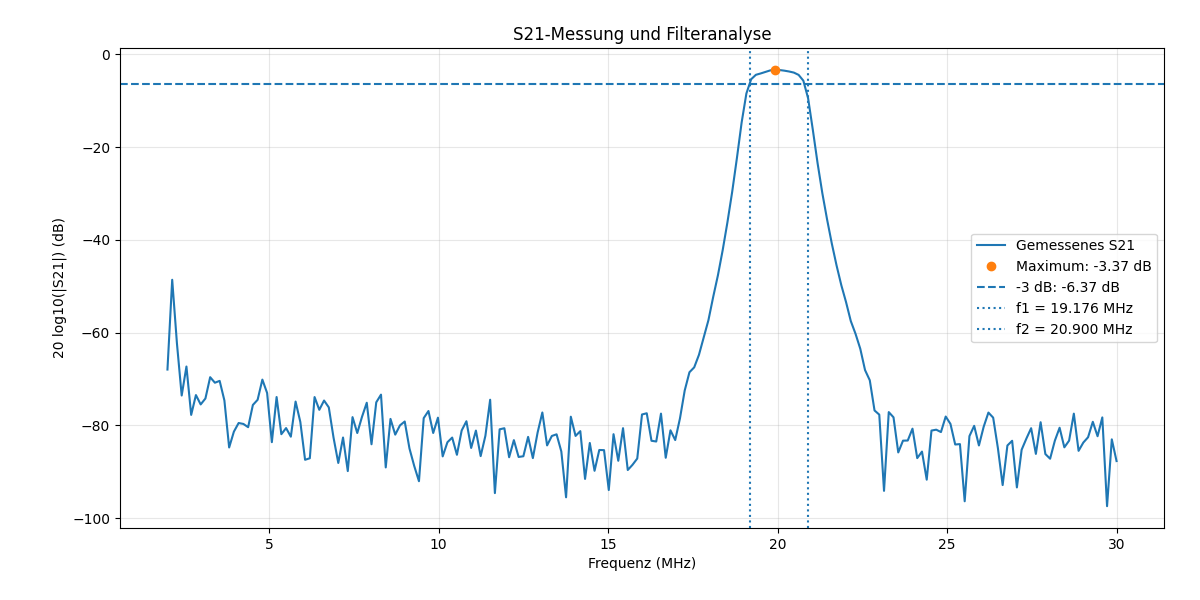

ERGEBNISSE

1. Filterart: Bandpass
2. Die 3-dB-Grenzfrequenzen liegen bei 19.175700 MHz und 20.900000 MHz.
   Filterbandbreite B = 1.724300 MHz.
3. Einfügungsdämpfung 3.370 dB.
4. maximale Filtersteilheit 1111.611 dB/Oktave bzw. 3692.693 dB/Dekade.
5. Bei T = 320 K beträgt die gefilterte Generator-Rauschleistung 3.1093e-15 W (0.0031 pW).


In [7]:
# ANALYSIS- PYTHON-Code HERE

import numpy as np
import matplotlib.pyplot as plt


# Messdaten vorbereiten

f = np.asarray(freq_hz, dtype=float)       # Frequenz in Hz
S21_dB = np.asarray(s21_db, dtype=float)   # 20 log10(|S21|) in dB

# Nach Frequenz sortieren, falls notwendig
idx_sort = np.argsort(f)
f = f[idx_sort]
S21_dB = S21_dB[idx_sort]

f_MHz = f / 1e6

# Filterdämpfung:
# S21_dB ist normalerweise <= 0 dB.
# Positive Dämpfung A(f) = -S21_dB
atten_dB = -S21_dB



# Filterart bestimmen

idx_max = np.argmax(S21_dB)
f_max = f[idx_max]
S21_max_dB = S21_dB[idx_max]

print("S21-ANALYSE DES HOCHFREQUENZ-FILTERS")


print(f"\nMaximale Transmission: {S21_max_dB:.3f} dB")
print(f"Frequenz der maximalen Transmission: {f_max/1e6:.6f} MHz")

# Allgemeine automatische Klassifikation anhand der Form
# Ein Bandpass besitzt einen Durchlassbereich innerhalb des
# Messbereichs mit schlechterer Transmission auf beiden Seiten.

threshold_3dB = S21_max_dB - 3.0
valid_3db = S21_dB >= threshold_3dB

if np.any(valid_3db):
    first = np.where(valid_3db)[0][0]
    last = np.where(valid_3db)[0][-1]

    if first > 0 and last < len(f) - 1:
        filter_type = "Bandpass"
    elif first == 0 and last < len(f) - 1:
        filter_type = "Tiefpass (bzw. Tiefpassbereich)"
    elif first > 0 and last == len(f) - 1:
        filter_type = "Hochpass (bzw. Hochpassbereich)"
    else:
        filter_type = "Innerhalb des Messbereichs nicht eindeutig bestimmbar."
else:
    filter_type = "Nicht eindeutig bestimmbar."

print(f"\nVermutete Filterart: {filter_type}")

# 3-dB-Grenzfrequenzen bestimmen


level_3db = S21_max_dB - 3.0

# Punkte oberhalb der -3-dB-Grenze
above = S21_dB >= level_3db

# Alle zusammenhängenden Bereiche suchen
changes = np.diff(above.astype(int))
starts = np.where(changes == 1)[0] + 1
ends = np.where(changes == -1)[0]

if above[0]:
    starts = np.r_[0, starts]

if above[-1]:
    ends = np.r_[ends, len(above)-1]

# Bereich auswählen, der das Maximum enthält
band_found = False

for start, end in zip(starts, ends):
    if start <= idx_max <= end:
        i1 = start
        i2 = end
        band_found = True
        break

if band_found:

    # Lineare Interpolation der beiden -3-dB-Schnittpunkte
    if i1 > 0:
        f_3db_low = np.interp(
            level_3db,
            [S21_dB[i1-1], S21_dB[i1]],
            [f[i1-1], f[i1]]
        )
    else:
        f_3db_low = f[i1]

    if i2 < len(f)-1:
        f_3db_high = np.interp(
            level_3db,
            [S21_dB[i2], S21_dB[i2+1]],
            [f[i2], f[i2+1]]
        )
    else:
        f_3db_high = f[i2]

    bandwidth = f_3db_high - f_3db_low

    print("\n--- 3-dB-Grenzen ---")
    print(f"3-dB-Pegel:       {level_3db:.3f} dB")
    print(f"Untere Grenzfrequenz: {f_3db_low/1e6:.6f} MHz")
    print(f"Obere Grenzfrequenz:  {f_3db_high/1e6:.6f} MHz")
    print(f"Filterbandbreite B:   {bandwidth/1e6:.6f} MHz")

else:
    print("\nKein zusammenhängender -3-dB-Durchlassbereich gefunden.")

# Einfügungsdämpfung


# Die minimale Dämpfung im Durchlassbereich entspricht
# dem maximalen S21-Wert.

insertion_loss_dB = -S21_max_dB

print("\n--- Einfügungsdämpfung ---")
print(f"Minimale Dämpfung / Einfügungsdämpfung: "
      f"{insertion_loss_dB:.3f} dB")



#  Maximaler Rolloff-Slope


# Für dB/Oktave:
#     slope_oct = dA / d(log2(f))
#
# Für dB/Dekade:
#     slope_dec = dA / d(log10(f))

log2_f = np.log2(f)
log10_f = np.log10(f)

slope_oct = np.gradient(atten_dB, log2_f)
slope_dec = np.gradient(atten_dB, log10_f)

# Betrag, weil wir die maximale Steilheit suchen
idx_rolloff = np.argmax(np.abs(slope_oct))

max_rolloff_oct = abs(slope_oct[idx_rolloff])
max_rolloff_dec = abs(slope_dec[idx_rolloff])

f_rolloff = f[idx_rolloff]

print("\n--- Maximaler Rolloff-Slope ---")
print(f"Frequenz:              {f_rolloff/1e6:.6f} MHz")
print(f"Max. Rolloff:          {max_rolloff_oct:.3f} dB/Oktave")
print(f"Max. Rolloff:          {max_rolloff_dec:.3f} dB/Dekade")


# Rauschleistung des Generators

# Johnson-Nyquist-Rauschleistung:
#
#     P_n = k * T * B
#
# k = Boltzmann-Konstante
# T = 320 K
# B = Filterbandbreite in Hz

k_B = 1.380649e-23       # J/K
T = 320.0                # K

if band_found:
    P_noise_in = k_B * T * bandwidth

    # Näherung:
    # Im Durchlassbereich wird die Rauschleistung entsprechend
    # |S21|^2 übertragen.
    #
    # Für eine genauere Auswertung wird die gemessene
    # Frequenzabhängigkeit von S21 integriert.

    S21_lin_power = 10**(S21_dB / 10.0)

    # Numerische Integration der gefilterten Rauschleistung:
    #
    # dP_out = k*T*|S21(f)|^2 df
    #
    P_noise_out = k_B * T * np.trapezoid(
        S21_lin_power,
        f
    )

    print("\n--- Generatorrauschen ---")
    print(f"Rauschtemperatur:          {T:.1f} K")
    print(f"Eingangsrauschleistung:    {P_noise_in:.4e} W")
    print(f"Eingangsrauschleistung:    {P_noise_in*1e12:.4f} pW")
    print(f"Gefilterte Rauschleistung:  {P_noise_out:.4e} W")
    print(f"Gefilterte Rauschleistung:  {P_noise_out*1e12:.4f} pW")
    print(f"Gefilterte Rauschleistung:  {P_noise_out*1e9:.6f} nW")



# Grafische Darstellung


fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(f_MHz, S21_dB, label="Gemessenes S21")

# Maximum
ax.plot(
    f_max / 1e6,
    S21_max_dB,
    "o",
    label=f"Maximum: {S21_max_dB:.2f} dB"
)

# 3-dB-Grenze und Grenzfrequenzen
if band_found:
    ax.axhline(
        level_3db,
        linestyle="--",
        label=f"-3 dB: {level_3db:.2f} dB"
    )

    ax.axvline(
        f_3db_low / 1e6,
        linestyle=":",
        label=f"f1 = {f_3db_low/1e6:.3f} MHz"
    )

    ax.axvline(
        f_3db_high / 1e6,
        linestyle=":",
        label=f"f2 = {f_3db_high/1e6:.3f} MHz"
    )

ax.set_xlabel("Frequenz (MHz)")
ax.set_ylabel("20 log10(|S21|) (dB)")
ax.set_title("S21-Messung und Filteranalyse")
ax.grid(True, alpha=0.3)
ax.legend()

# robust statt tight_layout()
fig.subplots_adjust(
    left=0.10,
    right=0.97,
    bottom=0.12,
    top=0.92
)

plt.show()


print("ERGEBNISSE")

print(f"\n1. Filterart: {filter_type}")

if band_found:
    print(f"2. Die 3-dB-Grenzfrequenzen liegen bei "f"{f_3db_low/1e6:.6f} MHz und "f"{f_3db_high/1e6:.6f} MHz.")

    print(f"   Filterbandbreite "f"B = {bandwidth/1e6:.6f} MHz.")

print(f"3. Einfügungsdämpfung "f"{insertion_loss_dB:.3f} dB.")

print(f"4. maximale Filtersteilheit "f"{max_rolloff_oct:.3f} dB/Oktave bzw. "f"{max_rolloff_dec:.3f} dB/Dekade.")

if band_found:
    print(f"5. Bei T = {T:.0f} K beträgt die gefilterte "f"Generator-Rauschleistung "f"{P_noise_out:.4e} W "f"({P_noise_out*1e12:.4f} pW).")